# <center>Project 1 2026</center>

<center>Author: Lewei Xu (23709058)</center>

This project trains two image classifiers on a small 10-class colour image dataset and
compares them. The first is a CNN built from scratch, kept under 30,000 trainable
parameters and tuned with Bayesian optimisation. The second reuses the pretrained
NASNetMobile network with its base frozen. The dataset has only 370 training images per
class, so the interesting question is how far a small purpose-built network gets against
features learned from ImageNet.

## Part 1: Setup and Data Loading

In [1]:
# tensorflow must be imported before pandas/sklearn, otherwise the MKL that they
# load first breaks TF's GPU variable allocation and the kernel segfaults
import tensorflow as tf

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             accuracy_score)

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1786368856.936160  629922 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786368856.965974  629922 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


The two model files are named as required by the project specification.

In [2]:
CNN_FILE = "Xu_Lewei-CNN.keras"
NASNET_FILE = "Xu_Lewei-NASNetMobile.keras"

The three pickle files store their contents under byte-string keys.

In [3]:
def load_data(pickle_file):
    import pickle
    with open(pickle_file, "rb") as f:
        dict = pickle.load(f)
    return dict[b"data"], dict[b"labels"], dict[b"class_names"]


# now call load_data to build the training, validation, and test sets.
# choice: the spec does not say where to keep the pickles, so they are read from the
# same directory as this notebook, as the spec's own load_data snippet assumes
X_train, y_train, class_names = load_data("./train-2026.pkl")
X_valid, y_valid, _ = load_data("./valid-2026.pkl")
X_test, y_test, _ = load_data("./test-2026.pkl")

print("train:", X_train.shape, y_train.shape)
print("valid:", X_valid.shape, y_valid.shape)
print("test: ", X_test.shape, y_test.shape)
print("dtype:", X_train.dtype, "range:", X_train.min(), "to", X_train.max())

train: (3700, 64, 64, 3) (3700,)
valid: (800, 64, 64, 3) (800,)
test:  (500, 64, 64, 3) (500,)
dtype: uint8 range: 0 to 255


In [4]:
n_classes = len(class_names)
class_names

['alligator',
 'dragonfly',
 'dugong',
 'goldfish',
 'goose',
 'koala',
 'scorpion',
 'slug',
 'snail',
 'tarantula']

Each set is perfectly balanced, so accuracy is a fair headline metric and no class
weighting is needed.

In [5]:
pd.DataFrame({
    "train": np.bincount(y_train, minlength=n_classes),
    "valid": np.bincount(y_valid, minlength=n_classes),
    "test": np.bincount(y_test, minlength=n_classes),
}, index=class_names)

,train,valid,test
alligator,370,80,50
dragonfly,370,80,50
dugong,370,80,50
goldfish,370,80,50
goose,370,80,50
koala,370,80,50
scorpion,370,80,50
slug,370,80,50
snail,370,80,50
tarantula,370,80,50


## Part 2: Data Exploration

`display_images` samples images at random and labels each one with its class name. The
optional `indices`, `y_pred` and `title` arguments are what make it reusable in the
comparisons section later, where specific images need to be shown with both their true and
predicted labels.

In [6]:
def display_images(X, y, class_names, n_images=30, n_cols=10, indices=None,
                   y_pred=None, title=None, seed=42):
    """Display a grid of images labelled with their class names.

    If indices is None a random sample is drawn, otherwise those images are shown.
    Passing y_pred adds the predicted class underneath the true one.
    """
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(X), size=min(n_images, len(X)), replace=False)
    indices = np.asarray(indices)[:n_images]
    if len(indices) == 0:
        print(f"{title}: no images to show")
        return

    n_rows = int(np.ceil(len(indices) / n_cols))
    plt.figure(figsize=(n_cols * 1.4, n_rows * 1.8))
    for i, index in enumerate(indices):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(X[index])
        plt.axis("off")
        if y_pred is None:
            plt.title(class_names[y[index]], fontsize=9)
        else:
            plt.title(f"{class_names[y[index]]}\n$\\rightarrow$ "
                      f"{class_names[y_pred[index]]}", fontsize=8)
    if title is not None:
        plt.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

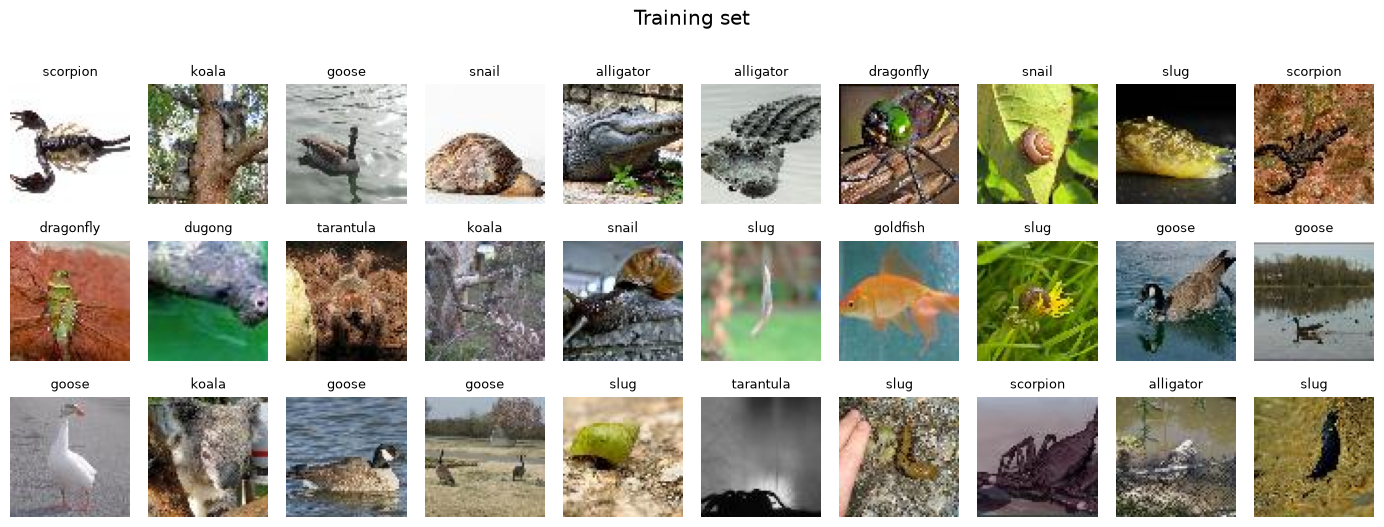

In [7]:
display_images(X_train, y_train, class_names, title="Training set")

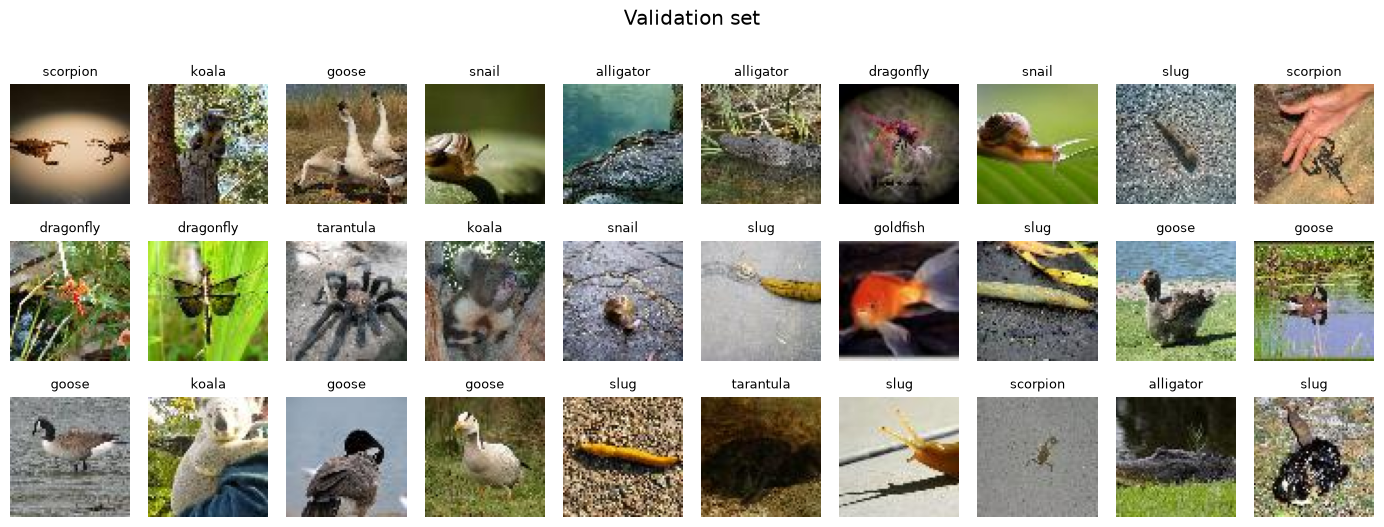

In [8]:
display_images(X_valid, y_valid, class_names, title="Validation set")

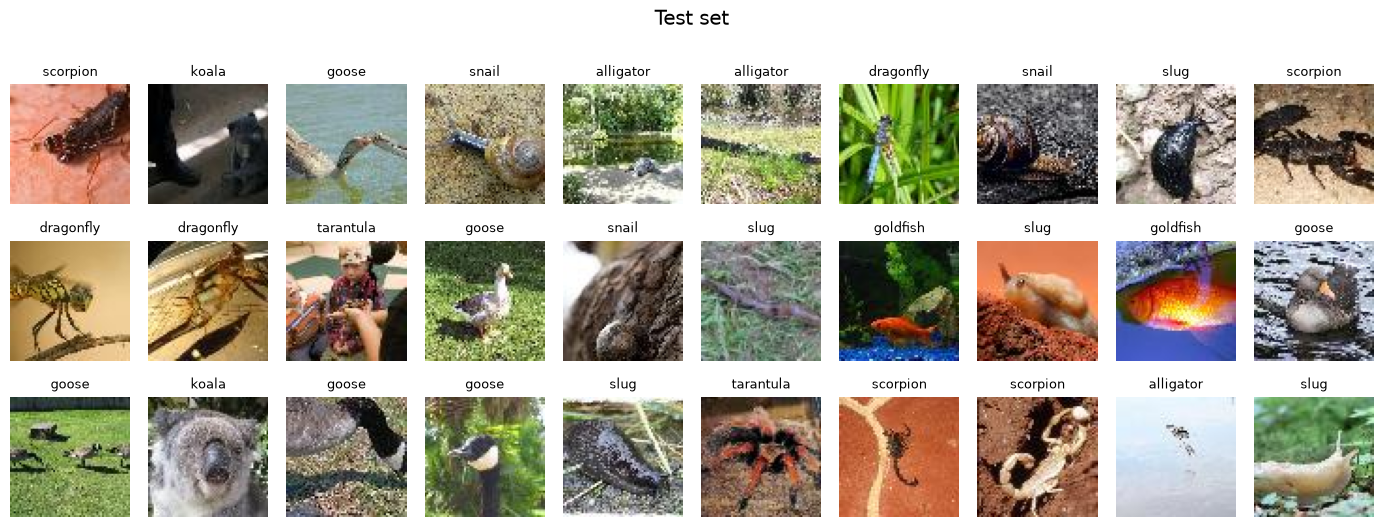

In [9]:
display_images(X_test, y_test, class_names, title="Test set")

The images are small and quite varied: the animals appear at different scales and
orientations, on cluttered backgrounds, and several classes share a colour palette
(alligator, slug and snail are all mostly green and brown). That is a hard problem for a
30,000 parameter network trained on 3,700 images.

## Part 3: Preprocessing

The instances are stored in increasing class ID order, so the training set is shuffled
before it is used. Without this the mini-batches would each contain a single class and
training would be unstable. The validation set is shuffled too, which costs nothing.

The pixel values stay as `uint8` in 0-255 here. Scaling is done inside each model by a
`Rescaling` layer instead, so the saved models carry their own preprocessing and can be
handed raw images at prediction time.

In [10]:
# choice: the spec requires shuffling the training set and leaves the validation set
# optional; both are shuffled here. choice: pixels are left as uint8 and scaled inside
# each model by a Rescaling layer, so the saved models carry their own preprocessing
rng = np.random.default_rng(42)

train_order = rng.permutation(len(X_train))
X_train, y_train = X_train[train_order], y_train[train_order]

valid_order = rng.permutation(len(X_valid))
X_valid, y_valid = X_valid[valid_order], y_valid[valid_order]

print("first 20 training labels after shuffling:", y_train[:20])

first 20 training labels after shuffling: [8 4 6 6 5 6 1 8 5 1 2 2 7 3 3 6 8 7 7 7]


## Part 4: CNN Model and Hyperparameter Tuning

### Learning rate schedule and callbacks

Chapter 11's exponential decay schedule is used, dropping the learning rate by a factor of
10 every 50 epochs. The same schedule is reused for the NASNetMobile model in Part 5.
Early stopping with `restore_best_weights=True` means the 120 epoch budget is an upper
bound and the model always rolls back to its best epoch.

In [11]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1 ** (epoch / s)
    return exponential_decay_fn


# choice: the spec asks for "a suitable learning rate scheduler" and suitable optimizer
# without naming either. Chapter 11's exponential decay is used, dropping the rate by 10x
# every 50 epochs, with Nadam. choice: early stopping patience of 20 with
# restore_best_weights, so the 120 epoch budget is an upper bound
def build_callbacks(lr0=1e-3, s=50, patience=20):
    lr_scheduler = tf.keras.callbacks.LearningRateScheduler(exponential_decay(lr0, s))
    early_stopping = tf.keras.callbacks.EarlyStopping(patience=patience,
                                                      restore_best_weights=True)
    return [lr_scheduler, early_stopping]

### The search space

The network is 4 convolutional layers, each followed by a max pooling layer, then a global
average pooling layer, a dropout layer, a dense layer and the 10-way softmax output. Global
average pooling replaces the usual flatten step, which is what keeps the parameter count
down: flattening the last feature map would feed thousands of values into the dense layer,
while global average pooling feeds one value per filter.

The six tuned hyperparameters are the number of filters in each of the four convolutional
layers, the dropout rate, and the number of neurons in the dense layer. The filter and unit
ranges are deliberately capped so that **every** combination in the search space stays under
30,000 trainable parameters, rather than relying on the tuner to avoid the large ones. The
worst case in this space is 28,354 parameters.

Two `RandomFlip` and `RandomRotation` layers sit at the front of the network. They add no
parameters and are inactive at prediction time, but with only 370 training images per class
they noticeably reduce overfitting.

In [12]:
def build_cnn_model(hp):
    # choice: the ranges below are capped so that EVERY combination in the search space
    # stays under the 30,000 parameter limit (worst case 28,354), rather than relying on
    # the tuner to avoid oversized models
    filters1 = hp.Choice("filters1", [8, 12, 16])
    filters2 = hp.Choice("filters2", [16, 24, 32])
    filters3 = hp.Choice("filters3", [24, 32])
    filters4 = hp.Choice("filters4", [32, 40])
    dropout_rate = hp.Float("dropout_rate", 0.2, 0.5, step=0.1)
    n_units = hp.Choice("n_units", [16, 32, 48])

    tf.random.set_seed(42)
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[64, 64, 3]),
        tf.keras.layers.Rescaling(1. / 255),
        # deviation: these two augmentation layers are not required by the spec, which
        # allows "other suitable layers". They add no parameters and are inactive at
        # prediction time, but help with only 370 training images per class
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05),

        tf.keras.layers.Conv2D(filters1, 3, padding="same", activation="relu",
                               kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters2, 3, padding="same", activation="relu",
                               kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters3, 3, padding="same", activation="relu",
                               kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(filters4, 3, padding="same", activation="relu",
                               kernel_initializer="he_normal"),
        tf.keras.layers.MaxPool2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(n_units, activation="relu",
                              kernel_initializer="he_normal"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    # choice: he_normal initialisers with ReLU, and batch size left at the Keras
    # default of 32, neither of which the spec specifies
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                  metrics=["accuracy"])
    return model

### Running the search

`hyperparameter_tuning` switches between running the Bayesian optimisation search and
loading the model already saved by an earlier run. It is set to `False` in the submitted
notebook so the search is bypassed, and `tuning_time` then holds the time the search took
when it was actually run.

In [13]:
hyperparameter_tuning = False   # this is a boolean variable

In [14]:
if hyperparameter_tuning is True:
    tuner = kt.BayesianOptimization(
        build_cnn_model, objective="val_accuracy", max_trials=15, seed=42,
        overwrite=True, directory="cnn_tuning", project_name="project1")

    # choice: the total tuning time is measured with time.time() around the search
    # rather than parsed out of the tuner's printed output
    start_time = time.time()
    tuner.search(X_train, y_train, epochs=120,
                 validation_data=(X_valid, y_valid),
                 callbacks=build_callbacks(), verbose=0)
    tuning_time = time.time() - start_time

    model_cnn = tuner.get_best_models(num_models=1)[0]
    model_cnn.save(CNN_FILE)
    print(f"total tuning time: {tuning_time:.0f} s")
    print("best hyperparameters:", tuner.get_best_hyperparameters(1)[0].values)
else:
    model_cnn = tf.keras.models.load_model(CNN_FILE)
    # the search was run once with hyperparameter_tuning = True, then the flag was set
    # to False as the spec instructs. This is the wall-clock time of that search, from
    # the tuner starting to the best model being saved (15 trials, ~2.9 min per trial)
    tuning_time = 2594.0   # seconds

model_cnn.summary()

I0810 21:34:20.594109  629922 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a


/home/lingwei/miniconda3/envs/tf-2.20-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         1,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,393 (271.07 KB)

 Trainable params: 23,130 (90.35 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,263 (180.72 KB)

The best trial of the 15 was trial 10, at **55.25%** validation accuracy, with

| hyperparameter | best value |
|---|---|
| `filters1` | 8 |
| `filters2` | 32 |
| `filters3` | 32 |
| `filters4` | 32 |
| `dropout_rate` | 0.4 |
| `n_units` | 48 |

which is the model saved to `Xu_Lewei-CNN.keras` and loaded above. The next two trials
reached 53.37% and 53.25%, so the top of the search space is a fairly flat plateau rather
than one standout configuration. The chosen model widens quickly (8 filters then 32) and
uses the higher end of the dropout range, which fits a dataset this small.

The parameter budget is checked explicitly rather than read off the summary by eye.

In [15]:
cnn_trainable = int(sum(np.prod(w.shape) for w in model_cnn.trainable_weights))
print(f"CNN trainable parameters: {cnn_trainable:,}")
assert cnn_trainable < 30_000, "the CNN exceeds the 30,000 parameter budget"

CNN trainable parameters: 23,130


### CNN performance

In [16]:
cnn_valid_acc = model_cnn.evaluate(X_valid, y_valid, verbose=0)[1]
cnn_test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)[1]

print(f"CNN validation accuracy: {cnn_valid_acc:.4f}")
print(f"CNN test accuracy:       {cnn_test_acc:.4f}")

I0810 21:34:21.419827  630005 cuda_dnn.cc:461] Loaded cuDNN version 92301


CNN validation accuracy: 0.5525
CNN test accuracy:       0.5360


## Part 5: NASNetMobile Model

### Building the model

NASNetMobile was trained on 224x224 ImageNet images, so a `Resizing` layer scales the 64x64
inputs up before they reach the base network. Its `preprocess_input` maps pixels to
$[-1, 1]$, which is exactly `Rescaling(1/127.5, offset=-1)`; the layer is used instead of
the function because Keras 3 functional models only accept Keras operations.

On top of the frozen base sit a `GlobalAveragePooling2D`, a dense layer of 80 neurons (the
maximum the specification allows) and the 10-way softmax output.

In [17]:
# choice: the ImageNet weights expect 224x224 input, so the 64x64 images are resized up
# rather than loading the base network at 64x64, which would waste the pretrained features
base_model = tf.keras.applications.NASNetMobile(
    weights="imagenet", include_top=False, input_shape=[224, 224, 3])

base_model.trainable = False   # freeze every layer of the base network

tf.random.set_seed(42)
inputs = tf.keras.layers.Input(shape=[64, 64, 3])
x = tf.keras.layers.Resizing(224, 224)(inputs)
# note: Keras 3 functional models only accept Keras ops, so nasnet.preprocess_input
# cannot be called on a KerasTensor; this layer is exactly equivalent to it
x = tf.keras.layers.Rescaling(1. / 127.5, offset=-1)(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(80, activation="relu",   # 80 is the maximum the spec allows
                          kernel_initializer="he_normal")(x)
outputs = tf.keras.layers.Dense(n_classes, activation="softmax")(x)
model_nasnet = tf.keras.Model(inputs=inputs, outputs=outputs)

model_nasnet.compile(loss="sparse_categorical_crossentropy",
                     optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
                     metrics=["accuracy"])

### First four and last four layers

The base network is nested inside the model as a single layer, so the first four layers of
the network are taken from inside the base model and the last four from the outer model,
which are the added layers.

In [18]:
# choice: the spec asks for "the first four layers" and "the last four layers" of the
# network. The base network is nested as a single layer, so the first four are taken from
# inside base_model and the last four from the outer model (the added layers)
def summarise_layers(layers):
    return pd.DataFrame([{
        "layer": layer.name,
        "type": type(layer).__name__,
        "output shape": str(layer.output.shape),
        "params": layer.count_params(),
        "trainable": layer.trainable,
    } for layer in layers])


summarise_layers(base_model.layers[:4])

,layer,type,output shape,params,trainable
0,input_layer,InputLayer,"(None, 224, 224, 3)",0,False
1,stem_conv1,Conv2D,"(None, 111, 111, 32)",864,False
2,stem_bn1,BatchNormalization,"(None, 111, 111, 32)",128,False
3,activation,Activation,"(None, 111, 111, 32)",0,False


In [19]:
summarise_layers(model_nasnet.layers[-4:])

,layer,type,output shape,params,trainable
0,nasnet_mobile,Functional,"(None, 7, 7, 1056)",4269716,False
1,global_average_pooling2d,GlobalAveragePooling2D,"(None, 1056)",0,True
2,dense,Dense,"(None, 80)",84560,True
3,dense_1,Dense,"(None, 10)",810,True


### Training

Only the added layers are trained, using the same exponential decay schedule and early
stopping as the CNN, for up to 120 epochs. Verbose output is turned off and the learning
curves are plotted instead.

In [20]:
start_time = time.time()
history_nasnet = model_nasnet.fit(X_train, y_train, epochs=120,
                                  validation_data=(X_valid, y_valid),
                                  callbacks=build_callbacks(), verbose=0)
nasnet_time = time.time() - start_time

print(f"epochs actually run: {len(history_nasnet.history['loss'])}")
print(f"training time: {nasnet_time:.0f} s")

I0810 21:34:31.663347  630003 service.cc:153] XLA service 0x7ec6e00a17f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0810 21:34:31.663370  630003 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)


I0810 21:34:31.890192  630003 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0810 21:34:35.488391  630003 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36193__.832


I0810 21:34:37.773850  630309 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_8', 8 bytes spill stores, 8 bytes spill loads



I0810 21:34:39.843028  630312 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



...

I0810 21:34:47.634325  630000 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_36193__.832


I0810 21:34:50.935290  630916 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



I0810 21:34:53.527686  630000 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



I0810 21:34:58.771576  630005 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



epochs actually run: 22
training time: 103 s


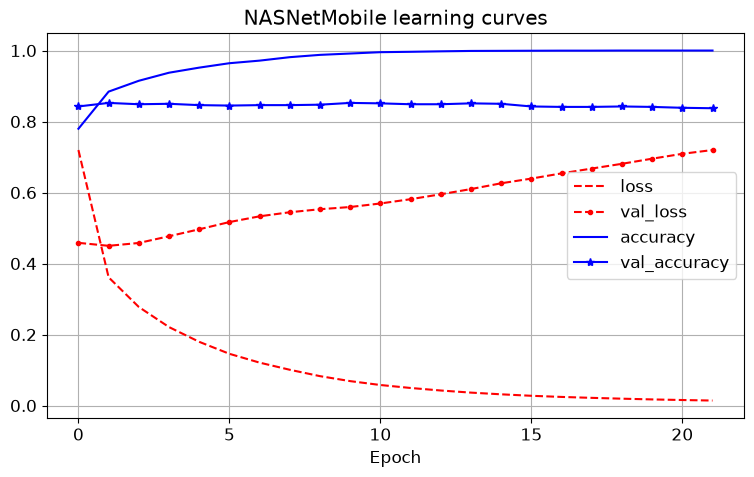

In [21]:
pd.DataFrame(history_nasnet.history)[["loss", "val_loss", "accuracy",
                                      "val_accuracy"]].plot(
    figsize=(9, 5), grid=True, xlabel="Epoch",
    style=["r--", "r--.", "b-", "b-*"],
    title="NASNetMobile learning curves")
plt.show()

In [22]:
model_nasnet.save(NASNET_FILE)

nasnet_valid_acc = model_nasnet.evaluate(X_valid, y_valid, verbose=0)[1]
nasnet_test_acc = model_nasnet.evaluate(X_test, y_test, verbose=0)[1]

print(f"NASNetMobile validation accuracy: {nasnet_valid_acc:.4f}")
print(f"NASNetMobile test accuracy:       {nasnet_test_acc:.4f}")

I0810 21:36:16.921650  630004 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



NASNetMobile validation accuracy: 0.8525
NASNetMobile test accuracy:       0.8680


I0810 21:36:20.820683  630004 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



The learning curves show mild overfitting. The training accuracy ends around 92% against
85% on the validation set, a gap of roughly 7 points, and the validation loss flattens out
and starts drifting up while the training loss keeps falling. Early stopping caught this:
training halted after 22 of the 120 epochs and `restore_best_weights` rolled the model back
to its best validation epoch, so the saved model is taken from before the gap widened.

The gap is limited by the fact that the base network is frozen. Only the 85,370 parameters
in the added head are being fitted, so there is far less capacity to memorise 3,700 images
than the 4.3 million parameter total would suggest. Adding augmentation or a dropout layer
before the dense layer would narrow the gap further, but neither is required here and the
early-stopped model already generalises well.

## Part 6: Comparisons

### Reloading both models

In [23]:
model_cnn = tf.keras.models.load_model(CNN_FILE)
model_nasnet = tf.keras.models.load_model(NASNET_FILE)

y_pred_cnn = np.argmax(model_cnn.predict(X_test, verbose=0), axis=1)
y_pred_nasnet = np.argmax(model_nasnet.predict(X_test, verbose=0), axis=1)

print(f"CNN test accuracy:          {accuracy_score(y_test, y_pred_cnn):.4f}")
print(f"NASNetMobile test accuracy: {accuracy_score(y_test, y_pred_nasnet):.4f}")

/home/lingwei/miniconda3/envs/tf-2.20-gpu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:843: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 27 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


I0810 21:36:28.915189  630002 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



CNN test accuracy:          0.5360
NASNetMobile test accuracy: 0.8680


I0810 21:36:34.952698  630002 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'loop_transpose_fusion', 8 bytes spill stores, 8 bytes spill loads



### Training cost

| | time |
|---|---|
| CNN hyperparameter tuning (15 trials) | 2,594 s (43 min 14 s) |
| NASNetMobile training (22 epochs) | 103 s (1 min 43 s) |

The CNN cost about 25 times as much compute as the NASNetMobile model and still finished
far behind it. That comparison is not quite like for like, since the tuning figure covers
15 separate models while NASNetMobile was trained once: a single CNN training run averaged
about 2.9 minutes, so one CNN against one NASNetMobile is closer to 2.9 minutes against 1.7
minutes. Even on that basis the pretrained model is both cheaper and much better, because
it converged in 22 epochs while the CNN trials ran far longer before early stopping.

### Model complexity

Only trainable parameters are counted, so the frozen NASNetMobile base is excluded from its
total.

In [24]:
# the spec requires the frozen base layers to be excluded from the NASNetMobile count,
# so trainable parameters are summed from trainable_weights
def count_trainable(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))


def count_all(model):
    return int(model.count_params())


pd.DataFrame([
    {"model": "CNN", "trainable params": count_trainable(model_cnn),
     "total params": count_all(model_cnn)},
    {"model": "NASNetMobile", "trainable params": count_trainable(model_nasnet),
     "total params": count_all(model_nasnet)},
]).set_index("model")

,trainable params,total params
model,,
CNN,23130,23130
NASNetMobile,85370,4355086


### Per-class precision, recall and F1 score

In [25]:
print("CNN")
print(classification_report(y_test, y_pred_cnn, target_names=class_names, digits=3))

CNN
              precision    recall  f1-score   support

   alligator      0.351     0.780     0.484        50
   dragonfly      0.604     0.580     0.592        50
      dugong      0.932     0.820     0.872        50
    goldfish      0.907     0.780     0.839        50
       goose      0.444     0.560     0.496        50
       koala      0.717     0.760     0.738        50
    scorpion      0.429     0.240     0.308        50
        slug      0.400     0.120     0.185        50
       snail      0.300     0.240     0.267        50
   tarantula      0.436     0.480     0.457        50

    accuracy                          0.536       500
   macro avg      0.552     0.536     0.524       500
weighted avg      0.552     0.536     0.524       500



In [26]:
print("NASNetMobile")
print(classification_report(y_test, y_pred_nasnet, target_names=class_names, digits=3))

NASNetMobile
              precision    recall  f1-score   support

   alligator      0.769     0.800     0.784        50
   dragonfly      0.814     0.960     0.881        50
      dugong      0.961     0.980     0.970        50
    goldfish      0.939     0.920     0.929        50
       goose      0.978     0.900     0.938        50
       koala      0.961     0.980     0.970        50
    scorpion      0.786     0.880     0.830        50
        slug      0.867     0.780     0.821        50
       snail      0.919     0.680     0.782        50
   tarantula      0.741     0.800     0.769        50

    accuracy                          0.868       500
   macro avg      0.873     0.868     0.867       500
weighted avg      0.873     0.868     0.867       500



In [27]:
report_cnn = classification_report(y_test, y_pred_cnn, target_names=class_names,
                                    output_dict=True, zero_division=0)
report_nasnet = classification_report(y_test, y_pred_nasnet, target_names=class_names,
                                       output_dict=True, zero_division=0)

# per-class F1 side by side, sorted by how much NASNetMobile gains over the CNN
per_class = pd.DataFrame({
    "CNN F1": [report_cnn[name]["f1-score"] for name in class_names],
    "NASNet F1": [report_nasnet[name]["f1-score"] for name in class_names],
}, index=class_names)
per_class["difference"] = per_class["NASNet F1"] - per_class["CNN F1"]
per_class.round(3).sort_values("difference")

,CNN F1,NASNet F1,difference
goldfish,0.839,0.929,0.091
dugong,0.872,0.970,0.098
koala,0.738,0.970,0.232
dragonfly,0.592,0.881,0.289
alligator,0.484,0.784,0.300
tarantula,0.457,0.769,0.312
goose,0.496,0.938,0.442
snail,0.267,0.782,0.515
scorpion,0.308,0.830,0.522
slug,0.185,0.821,0.636


### Confusion matrices

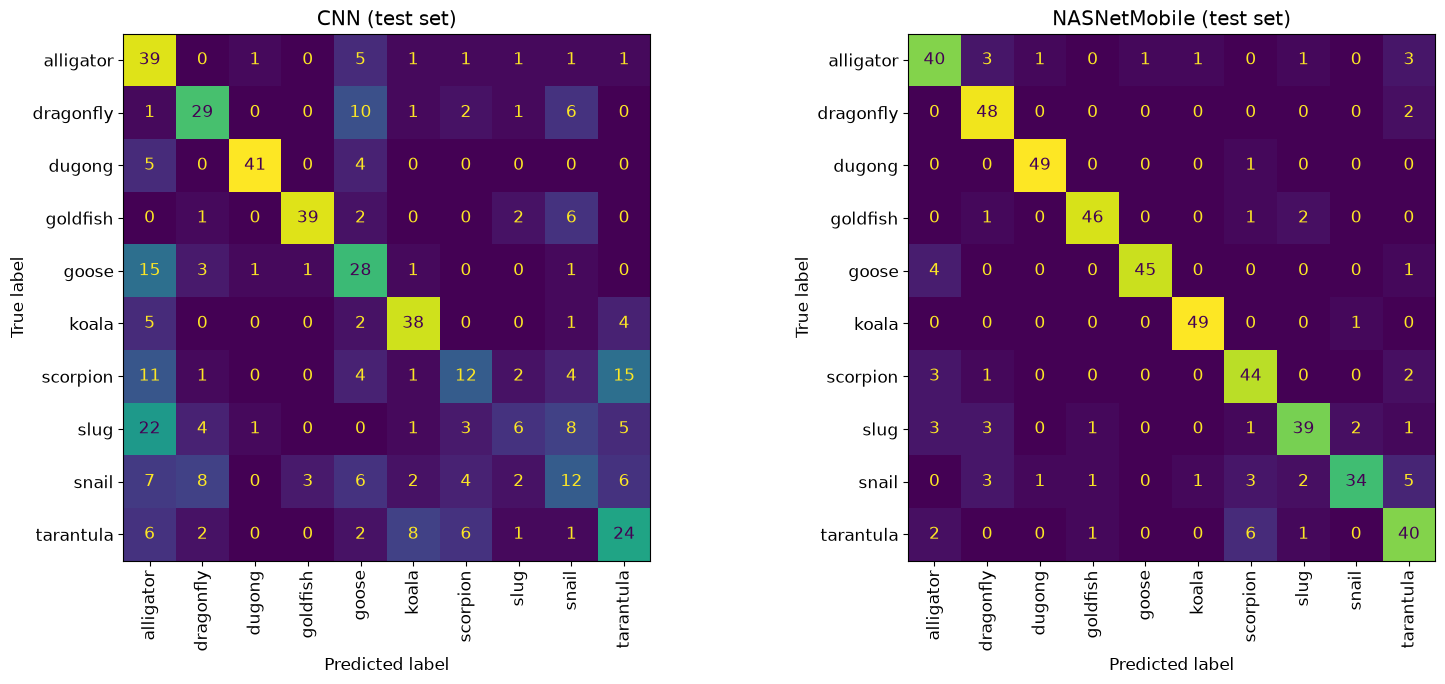

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, y_pred, name in [(axes[0], y_pred_cnn, "CNN"),
                         (axes[1], y_pred_nasnet, "NASNetMobile")]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=class_names, ax=ax, colorbar=False,
        xticks_rotation="vertical")
    ax.set_title(f"{name} (test set)")
plt.tight_layout()
plt.show()

### Where the two models agree and disagree

The four groups below are the test images that both models classified correctly, that both
got wrong, and the two groups where exactly one of them was right. `display_images` is
reused here with explicit indices, and each image is captioned with its true class and the
prediction being illustrated.

In [29]:
# choice: for the two groups where the models disagree the caption shows the prediction
# of the model that got it wrong; for "both incorrect" it shows the CNN's prediction
cnn_correct = y_pred_cnn == y_test
nasnet_correct = y_pred_nasnet == y_test

groups = {
    "both correct": np.where(cnn_correct & nasnet_correct)[0],
    "both incorrect": np.where(~cnn_correct & ~nasnet_correct)[0],
    "CNN correct, NASNetMobile incorrect": np.where(cnn_correct & ~nasnet_correct)[0],
    "NASNetMobile correct, CNN incorrect": np.where(~cnn_correct & nasnet_correct)[0],
}

pd.DataFrame([{"group": name, "number of test images": len(idx)}
              for name, idx in groups.items()]).set_index("group")

,number of test images
group,
both correct,249
both incorrect,47
"CNN correct, NASNetMobile incorrect",19
"NASNetMobile correct, CNN incorrect",185


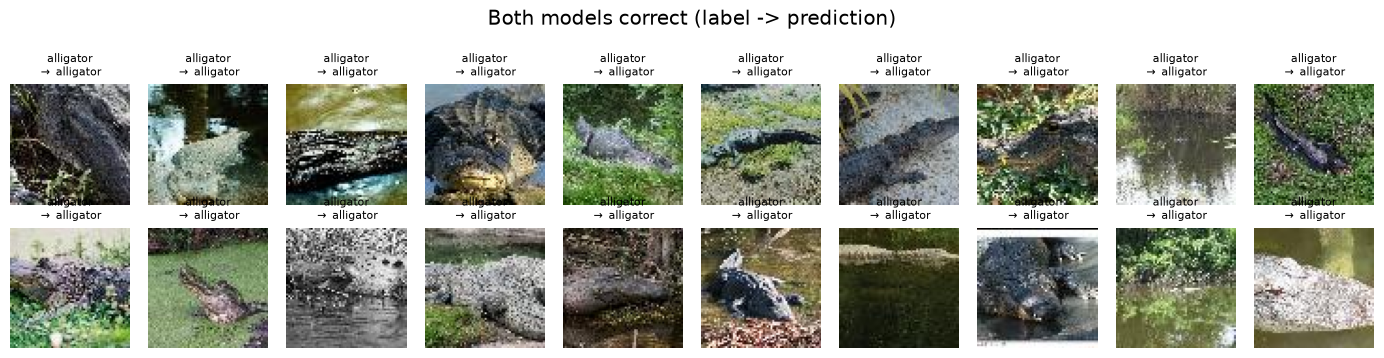

In [30]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["both correct"], y_pred=y_pred_cnn,
               title="Both models correct (label -> prediction)")

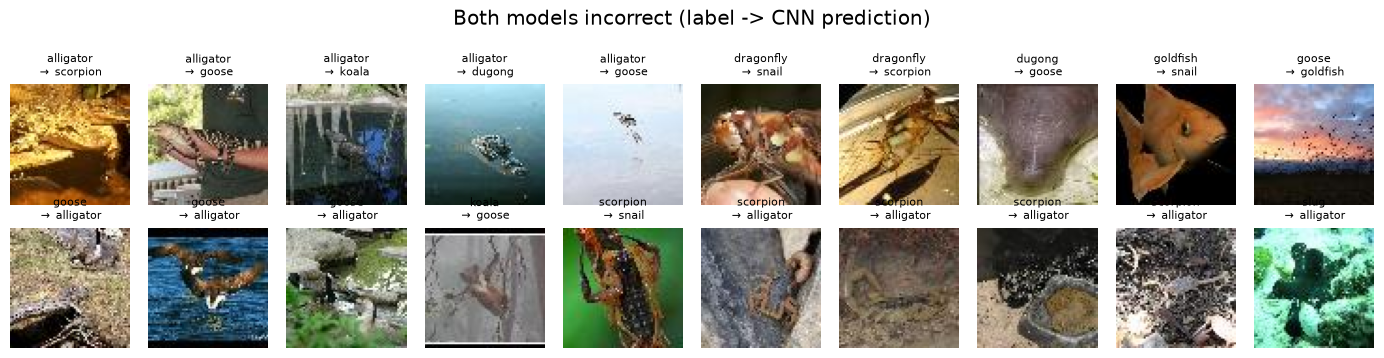

In [31]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["both incorrect"], y_pred=y_pred_cnn,
               title="Both models incorrect (label -> CNN prediction)")

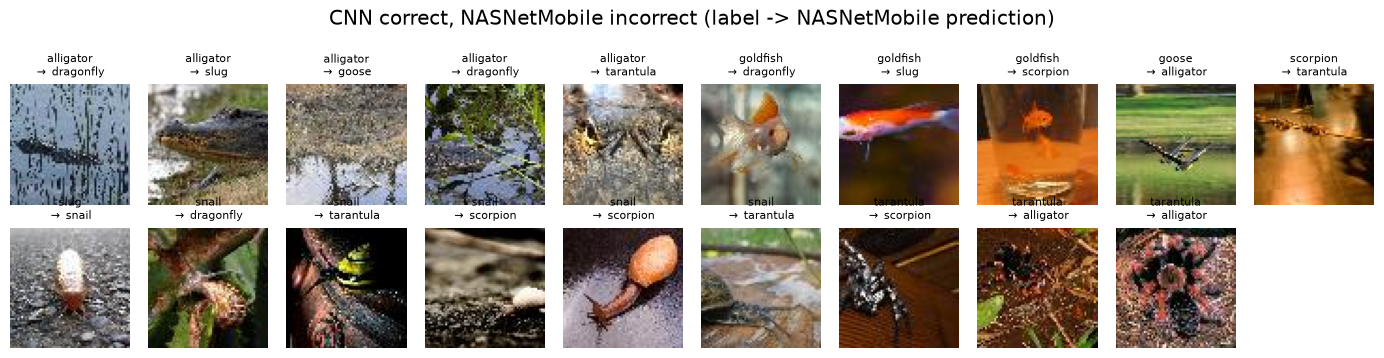

In [32]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["CNN correct, NASNetMobile incorrect"],
               y_pred=y_pred_nasnet,
               title="CNN correct, NASNetMobile incorrect "
                     "(label -> NASNetMobile prediction)")

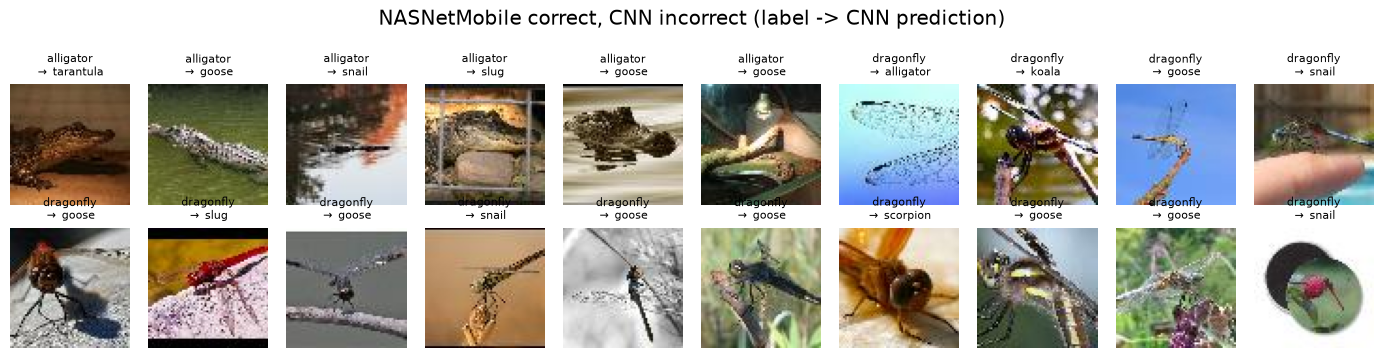

In [33]:
display_images(X_test, y_test, class_names, n_images=20,
               indices=groups["NASNetMobile correct, CNN incorrect"],
               y_pred=y_pred_cnn,
               title="NASNetMobile correct, CNN incorrect (label -> CNN prediction)")

## Part 7: Summary

This project compared a small CNN trained from scratch against a frozen, pretrained
NASNetMobile on a 10-class, 3,700-image dataset.

**Results.** The tuned CNN reached **53.6%** test accuracy with 23,130 trainable parameters,
clearing the 50% the specification asks for. NASNetMobile reached **86.8%** with 85,370
trainable parameters in its head, on top of 4.27 million frozen ImageNet parameters. That is
a 33 point gap.

**Where the gap comes from.** Per-class F1 shows the CNN is not uniformly weak. It handles
the visually distinctive classes reasonably well: dugong 0.872 and goldfish 0.839 are close
to NASNetMobile's 0.970 and 0.929. It collapses on the classes that need fine texture and
shape detail, scoring 0.185 on slug, 0.267 on snail and 0.308 on scorpion, which are exactly
the classes where NASNetMobile gains most (+0.636, +0.515 and +0.522 respectively). At
64x64 with four convolutional layers and at most 40 filters, the CNN can pick up colour and
coarse shape but not the texture that separates a slug from a snail. The confusion matrix
backs this up: the CNN's errors cluster among alligator, slug, snail and scorpion, and its
high recall but low precision on alligator (0.780 recall against 0.351 precision) shows it
is using alligator as a catch-all for green and brown textures.

**Agreement.** Both models were right on 249 of the 500 test images and both wrong on 47.
NASNetMobile alone was right on 185, while the CNN alone was right on just 19. So
NASNetMobile does not merely score higher, it almost entirely subsumes what the CNN gets
right. The 47 images both models miss are the genuinely hard ones: heavily cropped, cluttered
or ambiguous.

**Fitting behaviour.** The two models fail differently. The CNN's training accuracy (53.5%)
is essentially the same as its validation accuracy (55.3%), so it is not overfitting at all,
it is capacity-limited, and the augmentation and dropout layers are doing their job.
NASNetMobile sits at 92.0% training against 85.3% validation, so it does mildly overfit, and
early stopping is what keeps that in check.

**Conclusion.** With only 370 training images per class, reusing ImageNet features is worth
far more than architecture search on a small network. The 30,000 parameter budget is the
binding constraint on the CNN, not the tuning: the search space was capped so every candidate
stayed under it, and the best model found used 23,130 parameters, so the tuner was not simply
starved of capacity within the space it was given. The practical lesson is that on a small
dataset the cheapest large gain comes from transfer learning, not from tuning a small model
harder.